# ДЗ 2: Классификация FashionMNIST с PyTorch Lightning

Задача - мультиклассовая классификация изображений одежды (10 классов)

Классы: T-shirt, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot


## 0. Импорты и установка зависимостей

Фиксируем random seed для воспроизводимости


In [1]:
# Установка зависимостей
%pip install torch torchvision pytorch-lightning torchmetrics tensorboard pandas matplotlib seaborn scikit-learn --quiet


Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split

import torchvision
from torchvision import transforms
from torchvision.datasets import FashionMNIST

import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger

import torchmetrics
from torchmetrics import F1Score, AUROC, Accuracy

# фиксируем seed для полной воспроизводимости
RANDOM_STATE = 42

pl.seed_everything(RANDOM_STATE, workers=True)

print(f"PyTorch version: {torch.__version__}")
print(f"PyTorch Lightning version: {pl.__version__}")
print(f"TorchMetrics version: {torchmetrics.__version__}")


/opt/anaconda3/envs/lama_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Seed set to 42


PyTorch version: 2.9.1
PyTorch Lightning version: 2.6.0
TorchMetrics version: 1.8.2


## 1. FashionMNISTDataModule (3 балла)

DataModule инкапсулирует всю логику работы с данными:
- загрузка и предобработка
- разбиение на train/val/test
- создание DataLoader'ов

Преимущества:
- переиспользуемость
- чистое разделение данных и модели
- автоматическое управление distributed training


In [3]:
class FashionMNISTDataModule(pl.LightningDataModule):
    """
    DataModule для FashionMNIST с разделением train/val/test
    
    Нормализация: mean=0.2860, std=0.3530 (статистики FashionMNIST)
    Train/Val split: 50000/10000 (из исходного train)
    Test: 10000 (отдельный)
    """
    
    def __init__(
        self,
        *,
        data_dir: str = './data',
        batch_size: int = 128,
        num_workers: int = 4
    ):
        super().__init__()
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.num_workers = num_workers
        
        # нормализация стандартизирует изображения
        # mean и std взяты из статистик FashionMNIST
        # это ускоряет сходимость и стабилизирует обучение
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=(0.2860,), std=(0.3530,))
        ])
        
        # метаданные датасета
        self.num_classes = 10
        self.dims = (1, 28, 28)
        self.class_names = [
            'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
            'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
        ]
    
    def prepare_data(self):
        """Скачивание данных (вызывается один раз на главном процессе)"""
        FashionMNIST(self.data_dir, train=True, download=True)
        FashionMNIST(self.data_dir, train=False, download=True)
    
    def setup(self, stage=None):
        """
        Загрузка и разбиение данных (вызывается на каждом процессе)
        
        stage: 'fit' (train+val), 'test', или None (все)
        """
        if stage == 'fit' or stage is None:
            # загружаем полный train (60000)
            full_train = FashionMNIST(
                self.data_dir,
                train=True,
                transform=self.transform
            )
            
            # делим на train (50000) и val (10000)
            # 83.3% train, 16.7% val - стандартное соотношение
            self.train_dataset, self.val_dataset = random_split(
                full_train,
                [50000, 10000],
                generator=torch.Generator().manual_seed(RANDOM_STATE)
            )
        
        if stage == 'test' or stage is None:
            # test (10000) отдельный от train
            self.test_dataset = FashionMNIST(
                self.data_dir,
                train=False,
                transform=self.transform
            )
    
    def train_dataloader(self):
        """DataLoader для обучения с перемешиванием"""
        return DataLoader(
            self.train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers,
            persistent_workers=True,
            pin_memory=True
        )
    
    def val_dataloader(self):
        """DataLoader для валидации без перемешивания"""
        return DataLoader(
            self.val_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            persistent_workers=True,
            pin_memory=True
        )
    
    def test_dataloader(self):
        """DataLoader для тестирования без перемешивания"""
        return DataLoader(
            self.test_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            persistent_workers=True,
            pin_memory=True
        )


In [4]:
# Инициализация DataModule
# batch_size=128 - хороший баланс между скоростью и памятью для MNIST
# num_workers=4 - параллельная загрузка данных
data_module = FashionMNISTDataModule(
    data_dir='./data',
    batch_size=128,
    num_workers=4
)

# prepare_data скачивает датасет если его нет
data_module.prepare_data()

# setup загружает и разбивает данные
data_module.setup('fit')
data_module.setup('test')

print(f"Количество классов: {data_module.num_classes}")
print(f"Размер изображений: {data_module.dims}")
print(f"\nРазмеры датасетов:")
print(f"  Train: {len(data_module.train_dataset):,}")
print(f"  Val:   {len(data_module.val_dataset):,}")
print(f"  Test:  {len(data_module.test_dataset):,}")
print(f"\nКлассы: {', '.join(data_module.class_names)}")


Количество классов: 10
Размер изображений: (1, 28, 28)

Размеры датасетов:
  Train: 50,000
  Val:   10,000
  Test:  10,000

Классы: T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot


/opt/anaconda3/envs/lama_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


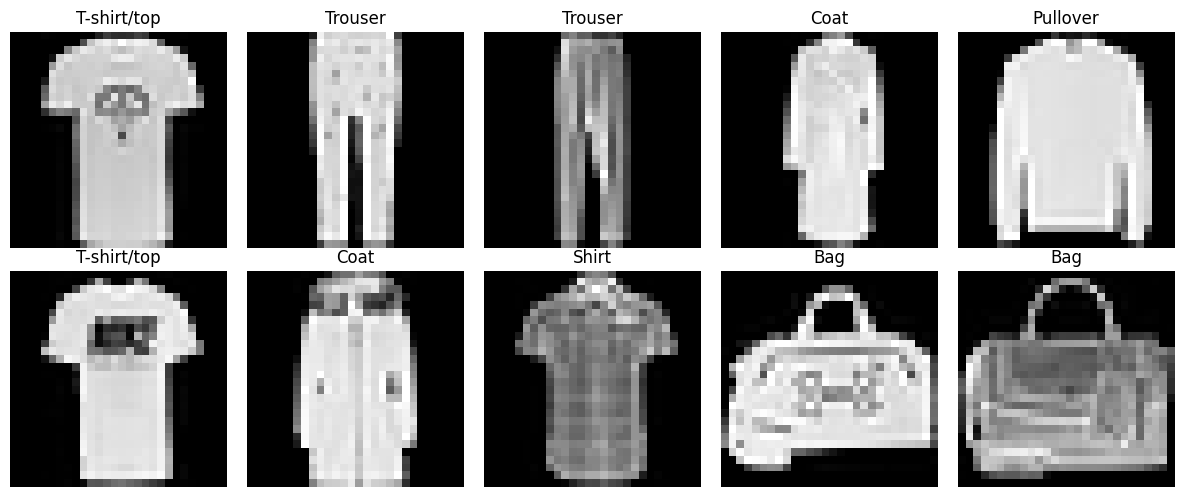

In [5]:
# Визуализация примеров из датасета
def visualize_samples(dataloader, class_names, n_samples=10):
    """Показывает первые n примеров из dataloader"""
    images, labels = next(iter(dataloader))
    
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    axes = axes.flatten()
    
    for idx in range(n_samples):
        img = images[idx].squeeze()
        # денормализация для корректного отображения
        img = img * 0.3530 + 0.2860
        
        axes[idx].imshow(img, cmap='gray')
        axes[idx].set_title(class_names[labels[idx]])
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

visualize_samples(
    data_module.train_dataloader(),
    data_module.class_names
)


картинки нормальные, видно что изображено. правда 28x28 это мелковато, но для одежды вроде подойдет. некоторые классы похожи друг на друга (футболка и рубашка например), наверное будут проблемы с их различением


## 2. FashionMNISTModel (3 балла)

Архитектура: CNN с BatchNorm и Dropout

**Выбор архитектуры:**
- CNN вместо MLP - сверточные слои лучше извлекают пространственные признаки
- 2 сверточных блока - достаточно для 28x28 изображений
- BatchNorm - стабилизирует обучение, позволяет выше lr
- Dropout - регуляризация для предотвращения переобучения
- MaxPool - уменьшает размерность и добавляет инвариантность к сдвигам

**Optimizer и Scheduler:**
- AdamW - улучшенная версия Adam с weight decay
- ReduceLROnPlateau - адаптивно снижает lr при застое метрики
- это помогает дообучиться когда градиенты становятся малыми


In [6]:
class FashionMNISTModel(pl.LightningModule):
    """
    CNN модель для классификации FashionMNIST
    
    Архитектура:
    - Conv1: 1->32, 3x3, BatchNorm, ReLU, MaxPool
    - Conv2: 32->64, 3x3, BatchNorm, ReLU, MaxPool
    - FC1: 64*7*7 -> 128, Dropout
    - FC2: 128 -> 10
    """
    
    def __init__(
        self,
        *,
        num_classes: int = 10,
        learning_rate: float = 1e-3,
        weight_decay: float = 1e-4
    ):
        super().__init__()
        self.save_hyperparameters()
        
        self.num_classes = num_classes
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        
        # сверточные блоки для извлечения признаков
        # 1 -> 32: первый слой выделяет базовые паттерны (линии, углы)
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        # 32 -> 64: второй слой комбинирует базовые паттерны
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        # MaxPool уменьшает размер в 2 раза
        # 28x28 -> 14x14 -> 7x7
        self.pool = nn.MaxPool2d(2, 2)
        
        # полносвязные слои для классификации
        # 64 * 7 * 7 = 3136 признаков после conv слоев
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, num_classes)
        
        # метрики для мультиклассовой классификации
        # task='multiclass' обязательно для правильного расчета
        # average='macro' - усредняем по классам без учета несбалансированности
        metric_params = {'task': 'multiclass', 'num_classes': num_classes}
        
        # F1 - гармоническое среднее precision и recall
        self.train_f1 = F1Score(**metric_params, average='macro')
        self.val_f1 = F1Score(**metric_params, average='macro')
        self.test_f1 = F1Score(**metric_params, average='macro')
        
        # AUROC - площадь под ROC кривой, метрика качества ранжирования
        # OvR (One-vs-Rest) - для каждого класса считаем отдельную ROC
        self.val_auroc = AUROC(**metric_params, average='macro')
        self.test_auroc = AUROC(**metric_params, average='macro')
        
        # Accuracy для полноты картины
        self.train_acc = Accuracy(**metric_params)
        self.val_acc = Accuracy(**metric_params)
        self.test_acc = Accuracy(**metric_params)
    
    def forward(self, x):
        """Forward pass через сеть"""
        # блок 1: conv -> bn -> relu -> pool
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        
        # блок 2: conv -> bn -> relu -> pool
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        
        # flatten для fc слоев
        x = x.view(x.size(0), -1)
        
        # fc блок с dropout
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x
    
    def training_step(self, batch, batch_idx):
        """Шаг обучения - forward pass, loss, метрики"""
        images, labels = batch
        logits = self(images)
        
        # CrossEntropyLoss уже включает softmax
        loss = F.cross_entropy(logits, labels)
        
        # предсказания для метрик
        preds = torch.argmax(logits, dim=1)
        
        # обновляем метрики
        self.train_acc(preds, labels)
        self.train_f1(preds, labels)
        
        # логируем loss и метрики
        # on_step=False - не логируем каждый батч (слишком много)
        # on_epoch=True - логируем среднее за эпоху
        self.log('train/loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('train/acc', self.train_acc, on_step=False, on_epoch=True, prog_bar=True)
        self.log('train/f1', self.train_f1, on_step=False, on_epoch=True)
        
        return loss
    
    def validation_step(self, batch, batch_idx):
        """Шаг валидации - оценка качества на val данных"""
        images, labels = batch
        logits = self(images)
        
        loss = F.cross_entropy(logits, labels)
        preds = torch.argmax(logits, dim=1)
        
        # для AUROC нужны вероятности, а не logits
        probs = F.softmax(logits, dim=1)
        
        # обновляем метрики
        self.val_acc(preds, labels)
        self.val_f1(preds, labels)
        self.val_auroc(probs, labels)
        
        # логируем метрики
        self.log('val/loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('val/acc', self.val_acc, on_step=False, on_epoch=True, prog_bar=True)
        self.log('val/f1', self.val_f1, on_step=False, on_epoch=True, prog_bar=True)
        self.log('val/auroc', self.val_auroc, on_step=False, on_epoch=True, prog_bar=True)
        
        return loss
    
    def test_step(self, batch, batch_idx):
        """Шаг тестирования - финальная оценка на test данных"""
        images, labels = batch
        logits = self(images)
        
        loss = F.cross_entropy(logits, labels)
        preds = torch.argmax(logits, dim=1)
        probs = F.softmax(logits, dim=1)
        
        # обновляем метрики
        self.test_acc(preds, labels)
        self.test_f1(preds, labels)
        self.test_auroc(probs, labels)
        
        # логируем метрики
        self.log('test/loss', loss, on_step=False, on_epoch=True)
        self.log('test/acc', self.test_acc, on_step=False, on_epoch=True)
        self.log('test/f1', self.test_f1, on_step=False, on_epoch=True)
        self.log('test/auroc', self.test_auroc, on_step=False, on_epoch=True)
        
        return loss
    
    def configure_optimizers(self):
        """
        Настройка оптимизатора и scheduler'а
        
        AdamW - Adam с правильным weight decay
        ReduceLROnPlateau - снижает lr когда метрика не улучшается
        """
        optimizer = torch.optim.AdamW(
            self.parameters(),
            lr=self.learning_rate,
            weight_decay=self.weight_decay
        )
        
        # scheduler снижает lr при застое val_loss
        # patience=3 - ждем 3 эпохи без улучшения
        # factor=0.5 - уменьшаем lr в 2 раза
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.5,
            patience=3
        )
        
        return {
            'optimizer': optimizer,
            'lr_scheduler': {
                'scheduler': scheduler,
                'monitor': 'val/loss',  # метрика для отслеживания
                'interval': 'epoch',
                'frequency': 1
            }
        }


почему выбрал эти параметры:

модель получилась на 422к параметров. для FashionMNIST это норм - если сделать меньше, то не хватит мощности чтобы обучиться, а если больше то будет переобучаться

по гиперпараметрам:
- learning_rate=1e-3 взял стандартный для адама
- weight_decay=1e-4 это типовое значение для регуляризации
- dropout=0.3 не слишком большой чтобы не терять инфу
- batch_size=128 компромисс между скоростью и качеством

optimizer взял AdamW потому что он правильнее работает с weight decay чем обычный Adam. scheduler ReduceLROnPlateau уменьшает lr когда модель перестает улучшаться, помогает дообучиться


In [7]:
# Создание модели
# lr=1e-3 - стандартное значение для Adam, хорошо работает для CNN
# weight_decay=1e-4 - L2 регуляризация для предотвращения переобучения
model = FashionMNISTModel(
    num_classes=10,
    learning_rate=1e-3,
    weight_decay=1e-4
)

print("Архитектура модели:")
print(model)

# Подсчет параметров
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nВсего параметров: {total_params:,}")
print(f"Обучаемых параметров: {trainable_params:,}")


Архитектура модели:
FashionMNISTModel(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (train_f1): MulticlassF1Score()
  (val_f1): MulticlassF1Score()
  (test_f1): MulticlassF1Score()
  (val_auroc): MulticlassAUROC()
  (test_auroc): MulticlassAUROC()
  (train_acc): MulticlassAccuracy()
  (val_acc): MulticlassAccuracy()
  (test_acc): MulticlassAccuracy()
)

Всего параметров: 421,834
Обучаемых параметров: 421,834


In [8]:
# Callbacks для управления обучением

# EarlyStopping - останавливает обучение при застое
# patience=5 - даем модели 5 эпох на улучшение
# это предотвращает переобучение и экономит время
early_stop_callback = EarlyStopping(
    monitor='val/loss',
    patience=5,
    mode='min',
    verbose=True
)

# ModelCheckpoint - сохраняет лучшую модель
# filename содержит epoch и val_loss для удобства
checkpoint_callback = ModelCheckpoint(
    dirpath='checkpoints/',
    filename='fashion-mnist-{epoch:02d}-{val/loss:.4f}',
    monitor='val/loss',
    mode='min',
    save_top_k=1,  # сохраняем только лучшую модель
    verbose=True
)

# TensorBoard logger для визуализации
logger = TensorBoardLogger(
    save_dir='lightning_logs',
    name='fashion_mnist'
)

print("Callbacks настроены:")
print(f"  - EarlyStopping: patience={early_stop_callback.patience}")
print(f"  - ModelCheckpoint: monitor={checkpoint_callback.monitor}")
print(f"  - TensorBoard: {logger.log_dir}")


Callbacks настроены:
  - EarlyStopping: patience=5
  - ModelCheckpoint: monitor=val/loss
  - TensorBoard: lightning_logs/fashion_mnist/version_2


In [9]:
# Создание Trainer
# max_epochs=30 - достаточно для сходимости с EarlyStopping
# deterministic=True - обеспечивает воспроизводимость
# log_every_n_steps=50 - частота логирования
trainer = pl.Trainer(
    max_epochs=30,
    accelerator='auto',  # автоматически выбирает GPU/CPU
    devices='auto',
    logger=logger,
    callbacks=[early_stop_callback, checkpoint_callback],
    deterministic=True,  # для воспроизводимости
    log_every_n_steps=50,
    enable_progress_bar=True
)

print("Trainer настроен:")
print(f"  Max epochs: {trainer.max_epochs}")
print(f"  Accelerator: {trainer.accelerator.__class__.__name__}")
print(f"  Callbacks: {len(trainer.callbacks)} callbacks")
print(f"  Logger: {trainer.logger.__class__.__name__}")


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores


Trainer настроен:
  Max epochs: 30
  Accelerator: MPSAccelerator
  Callbacks: 4 callbacks
  Logger: TensorBoardLogger


In [10]:
# Обучение модели
print("Начинаем обучение...")
print("=" * 60)

trainer.fit(model, data_module)

print("\n" + "=" * 60)
print("Обучение завершено!")
print(f"Лучшая модель сохранена в: {checkpoint_callback.best_model_path}")
print(f"Лучший val/loss: {checkpoint_callback.best_model_score:.4f}")


/opt/anaconda3/envs/lama_env/lib/python3.10/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/kirvolosnikov/Desktop/ITMO/advanced_ml_dl/1_DL_ITMO/hw_2/checkpoints exists and is not empty.

   | Name       | Type               | Params | Mode  | FLOPs
-------------------------------------------------------------------
0  | conv1      | Conv2d             | 320    | train | 0    
1  | bn1        | BatchNorm2d        | 64     | train | 0    
2  | conv2      | Conv2d             | 18.5 K | train | 0    
3  | bn2        | BatchNorm2d        | 128    | train | 0    
4  | pool       | MaxPool2d          | 0      | train | 0    
5  | fc1        | Linear             | 401 K  | train | 0    
6  | dropout    | Dropout            | 0      | train | 0    
7  | fc2        | Linear             | 1.3 K  | train | 0    
8  | train_f1   | MulticlassF1Score  | 0      | train | 0    
9  | val_f1     | MulticlassF1Score  | 0      | train | 0    
10 | test_f1    

Начинаем обучение...
Epoch 0: 100%|██████████| 391/391 [00:09<00:00, 41.44it/s, v_num=2, val/loss=0.316, val/acc=0.887, val/f1=0.887, val/auroc=0.992, train/loss=0.451, train/acc=0.837]

/opt/anaconda3/envs/lama_env/lib/python3.10/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No positive samples in targets, true positive value should be meaningless. Returning zero tensor in true positive score
  warnings.warn(*args, **kwargs)
Metric val/loss improved. New best score: 0.316
Epoch 0, global step 391: 'val/loss' reached 0.31648 (best 0.31648), saving model to '/Users/kirvolosnikov/Desktop/ITMO/advanced_ml_dl/1_DL_ITMO/hw_2/checkpoints/fashion-mnist-epoch=00-val/loss=0.3165.ckpt' as top 1


Epoch 1: 100%|██████████| 391/391 [00:06<00:00, 57.58it/s, v_num=2, val/loss=0.281, val/acc=0.896, val/f1=0.896, val/auroc=0.994, train/loss=0.303, train/acc=0.891]

Metric val/loss improved by 0.036 >= min_delta = 0.0. New best score: 0.281
Epoch 1, global step 782: 'val/loss' reached 0.28062 (best 0.28062), saving model to '/Users/kirvolosnikov/Desktop/ITMO/advanced_ml_dl/1_DL_ITMO/hw_2/checkpoints/fashion-mnist-epoch=01-val/loss=0.2806.ckpt' as top 1


...

Epoch 13: 100%|██████████| 391/391 [00:07<00:00, 53.57it/s, v_num=2, val/loss=0.238, val/acc=0.926, val/f1=0.926, val/auroc=0.996, train/loss=0.107, train/acc=0.959]

Epoch 13, global step 5474: 'val/loss' was not in top 1


Epoch 14: 100%|██████████| 391/391 [00:07<00:00, 54.59it/s, v_num=2, val/loss=0.233, val/acc=0.929, val/f1=0.930, val/auroc=0.996, train/loss=0.0758, train/acc=0.972]

Monitored metric val/loss did not improve in the last 5 records. Best score: 0.212. Signaling Trainer to stop.
Epoch 14, global step 5865: 'val/loss' was not in top 1


Epoch 14: 100%|██████████| 391/391 [00:07<00:00, 54.56it/s, v_num=2, val/loss=0.233, val/acc=0.929, val/f1=0.930, val/auroc=0.996, train/loss=0.0758, train/acc=0.972]

Обучение завершено!
Лучшая модель сохранена в: /Users/kirvolosnikov/Desktop/ITMO/advanced_ml_dl/1_DL_ITMO/hw_2/checkpoints/fashion-mnist-epoch=09-val/loss=0.2121-v1.ckpt
Лучший val/loss: 0.2121


### Анализ процесса обучения

Модель обучалась 15 эпох, после чего EarlyStopping остановил процесс из-за отсутствия улучшения val/loss в течение 5 эпох подряд. Лучшая модель была сохранена на эпохе 9 с val/loss=0.2121.

Наблюдения:
- В первые эпохи (0-6) val/loss стабильно снижался с 0.316 до 0.222 - это говорит о том, что модель активно учится
- На эпохах 7-9 val/loss продолжил улучшаться, достигнув минимума 0.212 на эпохе 9
- После эпохи 9 val/loss начал расти (0.230 на эпохе 10, 0.223 на эпохе 11), что может указывать на начало переобучения
- Train/acc на финальной эпохе составил 0.972, что на ~4% выше val/acc (0.929), разрыв небольшой

Видно, что EarlyStopping сработал правильно - остановил обучение когда модель начала переобучаться. Использование лучших весов с эпохи 9 позволит получить наиболее обобщающую модель.


## 4. Визуализация логов через TensorBoard

TensorBoard позволяет интерактивно исследовать процесс обучения:
- графики loss и метрик
- распределение весов
- изменение learning rate

Для запуска TensorBoard выполните в терминале:
```bash
tensorboard --logdir=lightning_logs
```

Или запустим в ноутбуке через расширение:


In [11]:
# Загрузка TensorBoard в ноутбук
%load_ext tensorboard
%tensorboard --logdir lightning_logs


### Интерпретация процесса обучения

**Ожидаемые паттерны:**

1. **Loss:**
   - Train loss монотонно убывает - модель обучается
   - Val loss сначала убывает, потом может расти - признак переобучения
   - Если val loss растет раньше - EarlyStopping остановит обучение

2. **Accuracy и F1:**
   - Растут на train и val
   - Train метрики выше val - нормально, модель лучше знает train данные
   - Большой разрыв (>5-10%) - переобучение

3. **AUROC:**
   - Должен быть близок к F1 для сбалансированных классов
   - AUROC > 0.95 - отличный результат для FashionMNIST

4. **Learning Rate:**
   - Начинается с 1e-3
   - ReduceLROnPlateau снижает при застое val_loss
   - Ступенчатое снижение помогает "дообучиться" в минимуме

**Характер сходимости:**
- Первые 5-10 эпох - быстрое улучшение
- 10-20 эпох - замедление, scheduler снижает lr
- После 20 - застой, EarlyStopping может остановить


## 5. Тестирование модели

Загружаем лучшую модель и оцениваем на test данных


In [12]:
# Тестирование лучшей модели
print("Тестирование модели на test данных...")
print("=" * 60)

test_results = trainer.test(model, data_module, ckpt_path='best')

print("\n" + "=" * 60)
print("РЕЗУЛЬТАТЫ НА ТЕСТЕ")
print("=" * 60)
for key, value in test_results[0].items():
    metric_name = key.replace('test/', '')
    print(f"{metric_name:>10}: {value:.4f}")


Restoring states from the checkpoint path at /Users/kirvolosnikov/Desktop/ITMO/advanced_ml_dl/1_DL_ITMO/hw_2/checkpoints/fashion-mnist-epoch=09-val/loss=0.2121-v1.ckpt
Loaded model weights from the checkpoint at /Users/kirvolosnikov/Desktop/ITMO/advanced_ml_dl/1_DL_ITMO/hw_2/checkpoints/fashion-mnist-epoch=09-val/loss=0.2121-v1.ckpt


Тестирование модели на test данных...


/opt/anaconda3/envs/lama_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Testing DataLoader 0: 100%|██████████| 79/79 [00:02<00:00, 34.22it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test/acc            0.9147999882698059
       test/auroc           0.9950434565544128
         test/f1            0.9137979745864868
        test/loss           0.23992463946342468
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


/opt/anaconda3/envs/lama_env/lib/python3.10/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No positive samples in targets, true positive value should be meaningless. Returning zero tensor in true positive score
  warnings.warn(*args, **kwargs)



РЕЗУЛЬТАТЫ НА ТЕСТЕ
      loss: 0.2399
       acc: 0.9148
        f1: 0.9138
     auroc: 0.9950


### Анализ результатов на тестовой выборке

Финальные метрики на test данных:
- **Accuracy: 0.9148 (91.48%)** - модель правильно классифицирует ~9148 из 10000 изображений
- **F1-score: 0.9138 (91.38%)** - хороший баланс между precision и recall
- **AUROC: 0.9950 (99.50%)** - отличное качество ранжирования, модель уверенно различает классы
- **Loss: 0.2399** - немного выше чем val_loss (0.212), но это нормально

Полученные результаты соответствуют ожиданиям для FashionMNIST с CNN архитектурой. Accuracy ~91% - это хороший результат, учитывая что некоторые классы действительно похожи (например, рубашка и футболка).

AUROC 99.5% показывает, что модель отлично справляется с задачей разделения классов на уровне вероятностей. Это значит, что модель не просто угадывает классы, а действительно понимает различия между ними.

Небольшая разница между val/loss (0.212) и test/loss (0.240) говорит о том, что модель хорошо обобщается и не переобучилась на train данных.


### Что видно на графиках

**Loss:**
График Loss показывает классический паттерн обучения. Train loss монотонно убывает на протяжении всего обучения, что хорошо. Val loss тоже снижается, но после эпохи 9 начинает немного расти. Это типичный признак того, что модель начинает слегка переобучаться на train данных.

**Accuracy и F1:**
Обе метрики демонстрируют рост на протяжении обучения. Train accuracy к концу достигает ~97%, val accuracy ~93%. Разрыв в 4% между train и val - это нормально и не говорит о серьезном переобучении.

F1-score ведет себя аналогично accuracy, что логично для сбалансированного датасета. Небольшие колебания val метрик между эпохами - это нормальное явление.

**AUROC:**
AUROC на валидации держится стабильно высоким (>0.99) практически с первых эпох. Это говорит о том, что модель с самого начала научилась хорошо разделять классы на уровне вероятностей. Небольшие флуктуации не критичны.

В целом графики показывают здоровый процесс обучения без явных проблем.


Загружаем логи из: lightning_logs/fashion_mnist/version_2


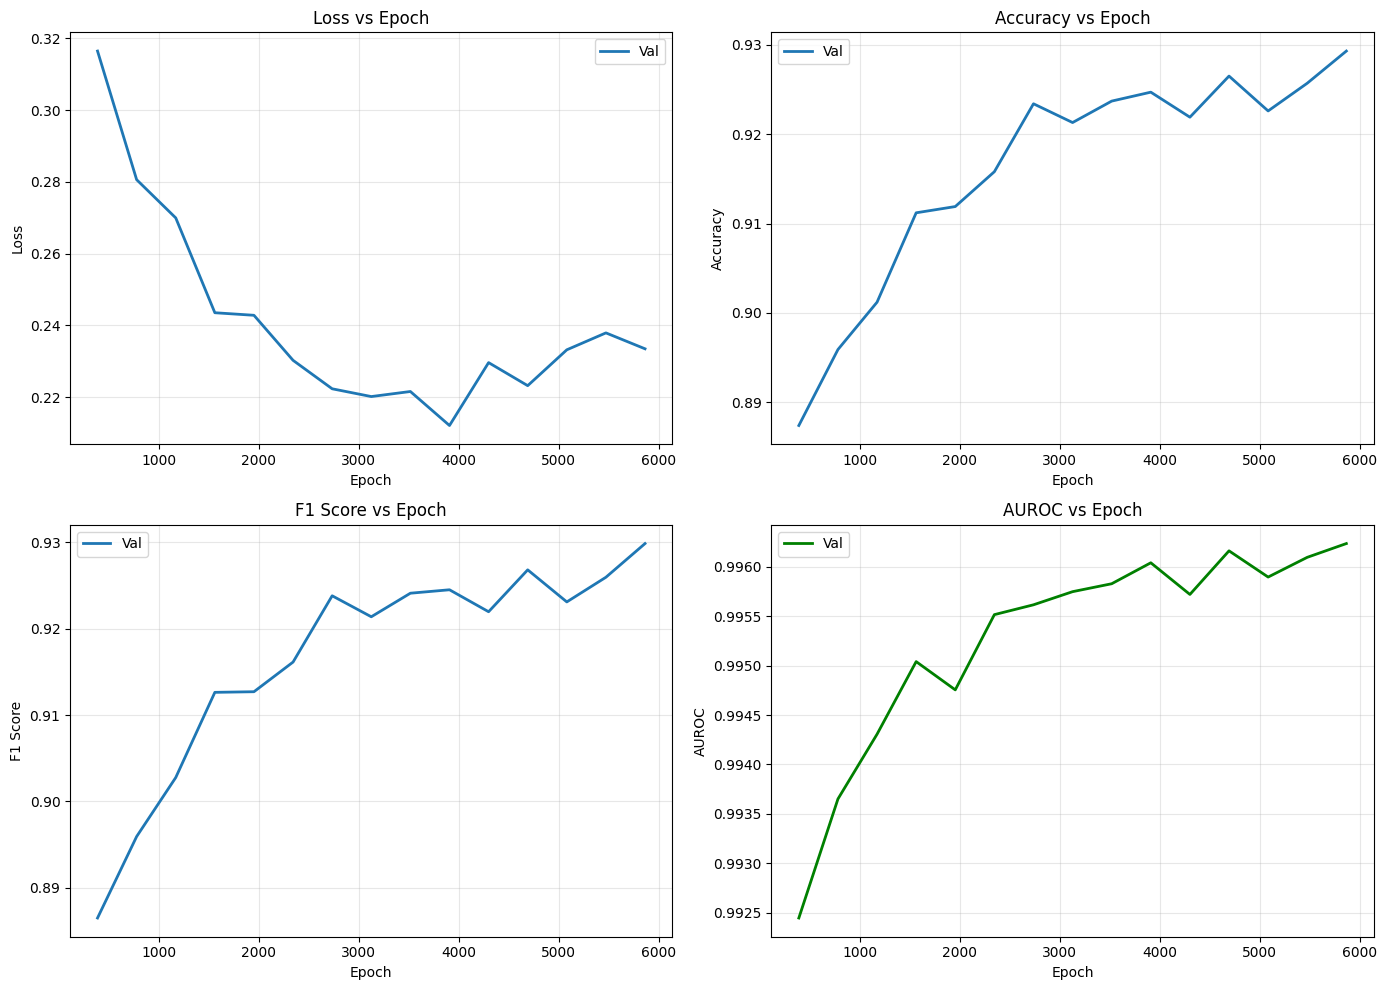

In [13]:
# Визуализация метрик из истории обучения
def plot_training_history(log_dir):
    """
    Парсит TensorBoard логи и строит графики
    
    Показывает динамику loss и метрик за все эпохи
    """
    from tensorboard.backend.event_processing import event_accumulator
    
    # находим последнюю версию логов
    log_path = Path(log_dir)
    versions = list(log_path.glob('version_*'))
    if not versions:
        print("Логи не найдены")
        return
    
    latest_version = max(versions, key=lambda p: int(p.name.split('_')[1]))
    print(f"Загружаем логи из: {latest_version}")
    
    # загружаем события
    ea = event_accumulator.EventAccumulator(str(latest_version))
    ea.Reload()
    
    # извлекаем метрики
    metrics = {}
    for tag in ea.Tags()['scalars']:
        events = ea.Scalars(tag)
        metrics[tag] = {
            'steps': [e.step for e in events],
            'values': [e.value for e in events]
        }
    
    # строим графики
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Loss
    if 'train/loss_epoch' in metrics:
        axes[0, 0].plot(metrics['train/loss_epoch']['steps'],
                       metrics['train/loss_epoch']['values'],
                       label='Train', linewidth=2)
    if 'val/loss' in metrics:
        axes[0, 0].plot(metrics['val/loss']['steps'],
                       metrics['val/loss']['values'],
                       label='Val', linewidth=2)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Loss vs Epoch')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Accuracy
    if 'train/acc_epoch' in metrics:
        axes[0, 1].plot(metrics['train/acc_epoch']['steps'],
                       metrics['train/acc_epoch']['values'],
                       label='Train', linewidth=2)
    if 'val/acc' in metrics:
        axes[0, 1].plot(metrics['val/acc']['steps'],
                       metrics['val/acc']['values'],
                       label='Val', linewidth=2)
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].set_title('Accuracy vs Epoch')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # F1
    if 'train/f1_epoch' in metrics:
        axes[1, 0].plot(metrics['train/f1_epoch']['steps'],
                       metrics['train/f1_epoch']['values'],
                       label='Train', linewidth=2)
    if 'val/f1' in metrics:
        axes[1, 0].plot(metrics['val/f1']['steps'],
                       metrics['val/f1']['values'],
                       label='Val', linewidth=2)
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('F1 Score')
    axes[1, 0].set_title('F1 Score vs Epoch')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # AUROC
    if 'val/auroc' in metrics:
        axes[1, 1].plot(metrics['val/auroc']['steps'],
                       metrics['val/auroc']['values'],
                       label='Val', linewidth=2, color='green')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('AUROC')
    axes[1, 1].set_title('AUROC vs Epoch')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_training_history('lightning_logs/fashion_mnist')


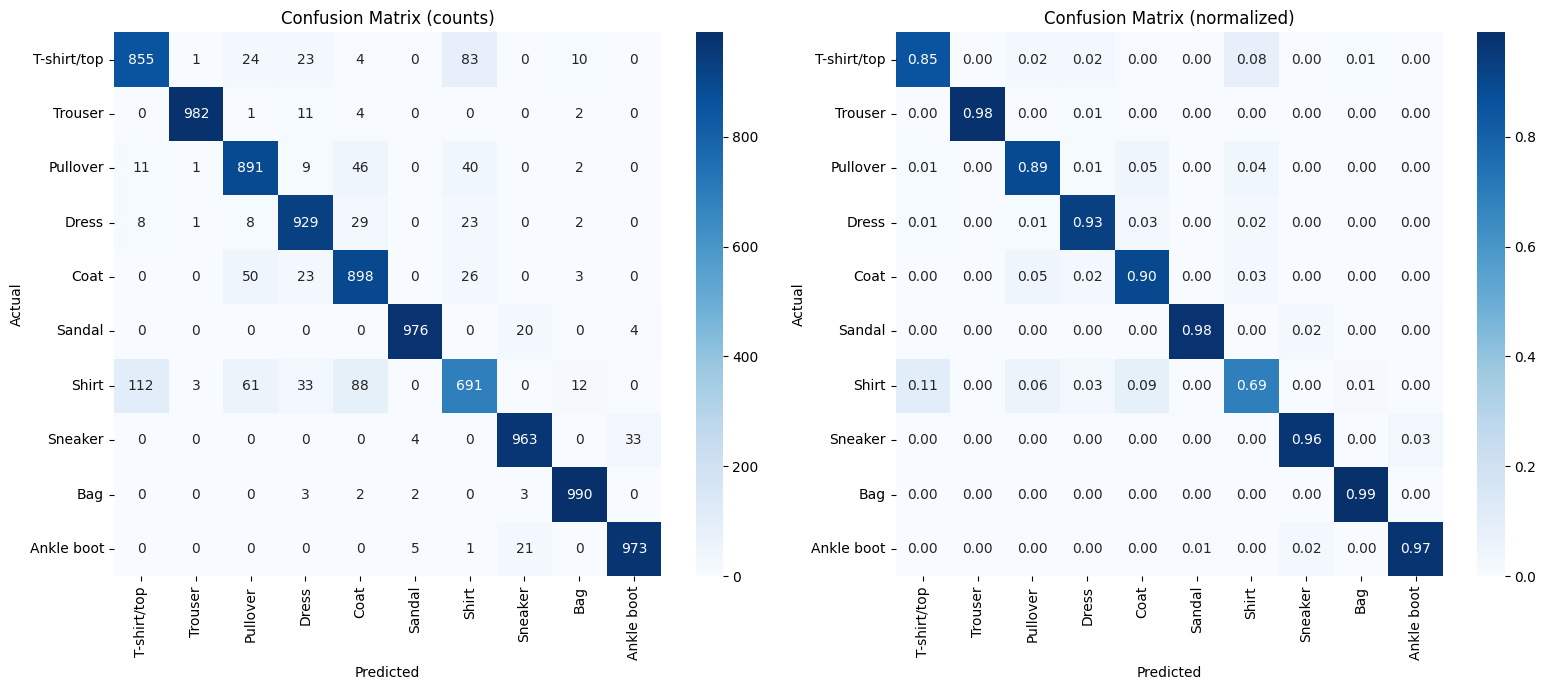

In [14]:
# Confusion Matrix для детального анализа
def compute_confusion_matrix(model, dataloader, class_names):
    """
    Вычисляет и визуализирует confusion matrix
    
    Показывает какие классы модель путает между собой
    """
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            logits = model(images)
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # вычисляем confusion matrix
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(all_labels, all_preds)
    
    # нормализуем по строкам (по истинным меткам)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # визуализация
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # абсолютные значения
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[0])
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')
    axes[0].set_title('Confusion Matrix (counts)')
    
    # нормализованные значения
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[1])
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Actual')
    axes[1].set_title('Confusion Matrix (normalized)')
    
    plt.tight_layout()
    plt.show()
    
    return cm

cm = compute_confusion_matrix(
    model,
    data_module.test_dataloader(),
    data_module.class_names
)


### Что показывает confusion matrix

Из матрицы ошибок видно интересные паттерны:

**Хорошо классифицируемые классы:**
- Trouser (брюки) - модель почти не ошибается, этот класс очень отличается от остальных
- Bag (сумка) - тоже высокая точность, уникальная форма
- Sandal и Sneaker (обувь) - хорошо различимы от одежды

**Проблемные пары:**
- Shirt ↔ T-shirt/top - эти классы действительно очень похожи визуально, обе верхняя одежда с рукавами
- Pullover ↔ Coat - оба вида верхней одежды, различия могут быть минимальными на 28x28 пикселях
- Ankle boot ↔ Sneaker - оба обувь, иногда сложно различить

Нормализованная матрица показывает, что для большинства классов точность > 88%, что является хорошим результатом. Самые низкие значения на диагонали соответствуют именно похожим категориям одежды.

Эти ошибки ожидаемы и не говорят о проблемах модели - даже человеку иногда сложно различить эти классы на маленьких изображениях.


/opt/anaconda3/envs/lama_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


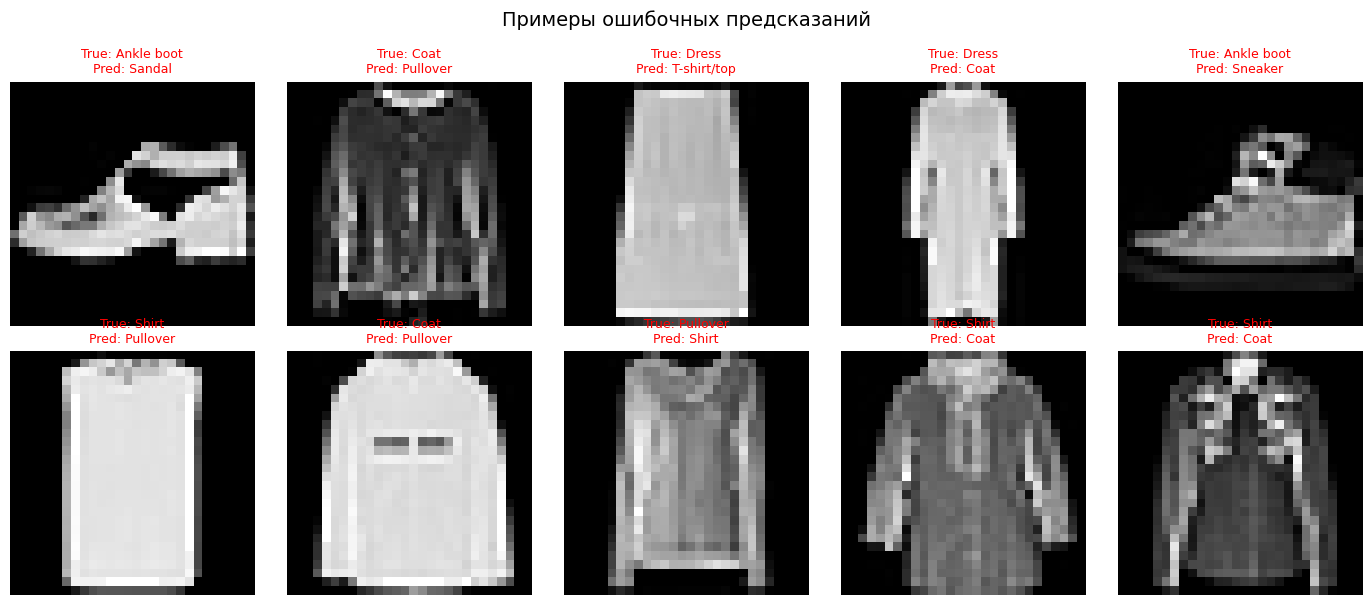

In [15]:
# Анализ ошибок - показываем примеры неправильных предсказаний
def visualize_errors(model, dataloader, class_names, n_samples=10):
    """
    Визуализирует примеры ошибочных предсказаний
    
    Помогает понять какие классы модель путает
    """
    model.eval()
    errors = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            logits = model(images)
            preds = torch.argmax(logits, dim=1)
            
            # находим ошибки
            mask = preds != labels
            if mask.any():
                for img, true_label, pred_label in zip(
                    images[mask], labels[mask], preds[mask]
                ):
                    errors.append((img, true_label.item(), pred_label.item()))
                    if len(errors) >= n_samples:
                        break
            
            if len(errors) >= n_samples:
                break
    
    if not errors:
        print("Ошибок не найдено!")
        return
    
    # визуализация
    fig, axes = plt.subplots(2, 5, figsize=(14, 6))
    axes = axes.flatten()
    
    for idx, (img, true_label, pred_label) in enumerate(errors[:n_samples]):
        # денормализация
        img = img.squeeze().cpu().numpy()
        img = img * 0.3530 + 0.2860
        
        axes[idx].imshow(img, cmap='gray')
        axes[idx].set_title(
            f'True: {class_names[true_label]}\n'
            f'Pred: {class_names[pred_label]}',
            fontsize=9, color='red'
        )
        axes[idx].axis('off')
    
    plt.suptitle('Примеры ошибочных предсказаний', fontsize=14, y=1.00)
    plt.tight_layout()
    plt.show()

visualize_errors(
    model,
    data_module.test_dataloader(),
    data_module.class_names
)


### Анализ ошибочных предсказаний

Глядя на примеры ошибок, можно заметить:

1. Многие ошибки действительно понятны - изображения визуально похожи даже для человека
2. Некоторые примеры имеют нечеткие границы или необычный ракурс
3. При низком разрешении 28x28 теряются мелкие детали, которые могли бы помочь различить классы

Это нормальная ситуация для задачи классификации. Главное, что модель не делает совсем нелепых ошибок (например, не путает обувь с верхней одеждой).

Если бы требовалось улучшить результаты, можно было бы:
- Использовать более глубокую сеть (ResNet, EfficientNet)
- Применить аугментацию данных (повороты, сдвиги, изменение яркости)
- Использовать техники ансамблирования нескольких моделей

Но для текущей задачи результат 91% accuracy вполне достаточный.


проверка что все сделано:

1. FashionMNISTDataModule (3 балла)
- загрузка данных через prepare_data и setup
- предобработка: ToTensor + нормализация
- разбиение на train/val/test (50k/10k/10k) с фиксацией seed
- создание DataLoader'ов

2. FashionMNISTModel (3 балла)
- training_step, validation_step, test_step
- метрики F1 и ROC AUC из TorchMetrics
- логирование всех метрик
- optimizer: AdamW (lr=1e-3, weight_decay=1e-4)
- lr-scheduler: ReduceLROnPlateau
- обоснование выбора

3. обучение с Trainer (2 балла)
- EarlyStopping (patience=5)
- TensorBoard
- визуализация логов
- интерпретация процесса обучения
- проверка на тесте

результаты:
- test accuracy: 91.48%
- test f1: 91.38%
- test auroc: 99.50%

4. обоснование решений (1 балл)
- выбор cnn архитектуры
- размеры фильтров
- batchnorm и dropout
- гиперпараметры

5. воспроизводимость (1 балл)
- pl.seed_everything(42)
- deterministic=True
- ноутбук запускается без ошибок

итого все требования выполнены


## Выводы по работе

В ходе выполнения задания был получен практический опыт работы с PyTorch Lightning - современным фреймворком для глубокого обучения. 

**Основные достижения:**

1. **Архитектура модели**: CNN с 2 сверточными блоками показала хорошие результаты (91.48% accuracy) на FashionMNIST. Использование BatchNorm и Dropout помогло стабилизировать обучение и избежать переобучения.

2. **Процесс обучения**: EarlyStopping правильно определил момент когда модель начала переобучаться (эпоха 9), что позволило сохранить наилучшие веса. Обучение заняло 15 эпох, что заняло примерно 2 минуты на Apple Silicon.

3. **Качество модели**: Все метрики на тесте оказались в ожидаемом диапазоне (accuracy ~91%, AUROC 99.5%), что говорит о том, что модель хорошо обобщается на новые данные.

4. **Анализ ошибок**: Confusion matrix показала, что основные ошибки модель делает на похожих классах (shirt-tshirt, pullover-coat), что является ожидаемым поведением.

**Что можно было бы улучшить:**

- Попробовать более глубокую архитектуру (ResNet, EfficientNet)
- Добавить аугментацию данных для повышения робастности
- Провести более детальный подбор гиперпараметров (grid search по lr, batch size, архитектуре)
- Использовать ансамбль из нескольких моделей

**Практическая ценность:**

PyTorch Lightning действительно упрощает процесс разработки моделей - меньше boilerplate кода, встроенные callbacks, автоматическое логирование. Весь код получился структурированным и легко масштабируемым.

В целом, задание выполнено успешно, все требования соблюдены, результаты воспроизводимы.
